# Análise Exploratória de Dados — Preços de Carros no Brasil

Notebook preparado para o exercício com a base `precos_carros_brasil.csv`.

## Tarefas
a. Carregar a base
b. Verificar valores faltantes e aplicar tratativa
c. Verificar dados duplicados
d. Separar colunas numéricas e categóricas e imprimir estatísticas descritivas
e. Imprimir contagem de valores por `model` e `brand`
f. Apresentar uma breve explicação final sobre os principais resultados


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 120)


In [2]:
# a) Carregar a base
arquivo = 'precos_carros_brasil.csv'
df = pd.read_csv(arquivo)

print('Base carregada com sucesso.')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
display(df.head())


Base carregada com sucesso.
Linhas: 267542 | Colunas: 11


C:\Users\leona\AppData\Local\Temp\ipykernel_29828\4286628314.py:3: DtypeWarning: Columns (0: month_of_reference, 1: fipe_code, 2: authentication, 3: brand, 4: model, 5: fuel, 6: gear, 7: engine_size) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002.0,9162.0
1,2021.0,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001.0,8832.0
2,2021.0,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000.0,8388.0
3,2021.0,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000.0,8453.0
4,2021.0,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001.0,12525.0


In [92]:
# Visão geral da estrutura da base
print('Informações gerais da base:')
df.info()


Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267542 entries, 0 to 267541
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   year_of_reference   202297 non-null  float64
 1   month_of_reference  202297 non-null  object 
 2   fipe_code           202297 non-null  object 
 3   authentication      202297 non-null  object 
 4   brand               202297 non-null  object 
 5   model               202297 non-null  object 
 6   fuel                202297 non-null  object 
 7   gear                202297 non-null  object 
 8   engine_size         202297 non-null  object 
 9   year_model          202297 non-null  float64
 10  avg_price_brl       202297 non-null  float64
dtypes: float64(3), object(8)
memory usage: 22.5+ MB


In [93]:
# b) Verificar valores faltantes
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().mean() * 100).round(2)

resumo_faltantes = pd.DataFrame({
    'qtd_faltantes': faltantes,
    'percentual_faltantes': faltantes_percentual
}).sort_values(by='qtd_faltantes', ascending=False)

print('Resumo de valores faltantes:')
display(resumo_faltantes)


Resumo de valores faltantes:


,qtd_faltantes,percentual_faltantes
year_of_reference,65245,24.39
month_of_reference,65245,24.39
fipe_code,65245,24.39
authentication,65245,24.39
brand,65245,24.39
model,65245,24.39
fuel,65245,24.39
gear,65245,24.39
engine_size,65245,24.39
year_model,65245,24.39


In [3]:
# Tratativa de valores faltantes
# Estratégia:
# - Colunas categóricas: preencher com 'Nao informado'
# - Colunas numéricas: preencher com a mediana

df_tratado = df.copy()

colunas_numericas = df_tratado.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()

for col in colunas_numericas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

for col in colunas_categoricas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna('Nao informado')

print('Valores faltantes após tratamento:')
display(df_tratado.isnull().sum())


C:\Users\leona\AppData\Local\Temp\ipykernel_29828\3231632065.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()


Valores faltantes após tratamento:


year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
dtype: int64

In [4]:
# c) Verificar dados duplicados
qtd_duplicados = df_tratado.duplicated().sum()
print(f'Quantidade de linhas duplicadas: {qtd_duplicados}')

if qtd_duplicados > 0:
    df_tratado = df_tratado.drop_duplicates().reset_index(drop=True)
    print('Duplicados removidos com sucesso.')
else:
    print('Não há duplicados para remover.')

print(f'Nova dimensão da base: {df_tratado.shape}')


Quantidade de linhas duplicadas: 65246
Duplicados removidos com sucesso.
Nova dimensão da base: (202296, 11)


In [96]:
# d) Separar colunas numéricas e categóricas
colunas_numericas = df_tratado.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()

print('Colunas numéricas:')
print(colunas_numericas)
print('\nColunas categóricas:')
print(colunas_categoricas)


Colunas numéricas:
['year_of_reference', 'year_model', 'avg_price_brl']

Colunas categóricas:
['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


In [97]:
# Estatística descritiva das variáveis numéricas
print('Resumo estatístico das variáveis numéricas:')
display(df_tratado[colunas_numericas].describe())


Resumo estatístico das variáveis numéricas:


,year_of_reference,year_model,avg_price_brl
count,202296.000000,202296.000000,202296.000000
mean,2021.564697,2011.271518,52756.692901
std,0.571903,6.376225,51628.794894
min,2021.000000,2000.000000,6647.000000
25%,2021.000000,2006.000000,22855.000000
50%,2022.000000,2012.000000,38027.000000
75%,2022.000000,2016.000000,64064.000000
max,2023.000000,2023.000000,979358.000000


In [98]:
# Estatística descritiva das variáveis categóricas
print('Resumo estatístico das variáveis categóricas:')
display(df_tratado[colunas_categoricas].describe())


Resumo estatístico das variáveis categóricas:


,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
count,202296,202296,202296,202296,202296,202296,202296,202296
unique,13,2092,202296,7,2113,4,3,30
top,January,003281-6,Nao informado,Fiat,Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p,Gasoline,manual,"1,6"
freq,24260,425,1,44962,425,168684,161883,47420


In [99]:
# e) Contagem de valores por modelo e marca
contagem_modelo = df_tratado['model'].value_counts().reset_index()
contagem_modelo.columns = ['model', 'quantidade']

contagem_marca = df_tratado['brand'].value_counts().reset_index()
contagem_marca.columns = ['brand', 'quantidade']

print('Contagem por modelo:')
display(contagem_modelo)

print('Contagem por marca:')
display(contagem_marca)


Contagem por modelo:


,model,quantidade
0,Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p,425
1,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,425
2,Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V,400
3,Focus 2.0 16V/SE/SE Plus Flex 5p Aut.,400
4,Golf 2.0/ 2.0 Mi Flex Aut/Tiptronic.,375
...,...,...
2108,KICKS Active 1.6 16V Flex Aut.,2
2109,Saveiro Robust 1.6 Total Flex 16V,2
2110,Polo Track 1.0 Flex 12V 5p,2
2111,Gol Last Edition 1.0 Flex 12V 5p,2


Contagem por marca:


,brand,quantidade
0,Fiat,44962
1,VW - VolksWagen,44312
2,GM - Chevrolet,38590
3,Ford,33150
4,Renault,29191
5,Nissan,12090
6,Nao informado,1


In [100]:
# f) Breve explicação final
print('Resumo final da análise:')
print('A base foi carregada e inspecionada quanto a valores faltantes e duplicados.')
print('Os valores ausentes foram tratados com mediana nas variáveis numéricas e com "Nao informado" nas categóricas.')
print('Também foram identificadas as distribuições das variáveis numéricas e categóricas, além da frequência por modelo e marca.')
print('Essas análises ajudam a entender a composição da base e a preparar os dados para análises futuras.')


Resumo final da análise:
A base foi carregada e inspecionada quanto a valores faltantes e duplicados.
Os valores ausentes foram tratados com mediana nas variáveis numéricas e com "Nao informado" nas categóricas.
Também foram identificadas as distribuições das variáveis numéricas e categóricas, além da frequência por modelo e marca.
Essas análises ajudam a entender a composição da base e a preparar os dados para análises futuras.


## 2 Visualização dos dados

A partir da base de dados `precos_carros_brasil.csv`, execute as seguintes tarefas: 


**a.** Gere um gráfico da distribuição da quantidade de carros por marca.

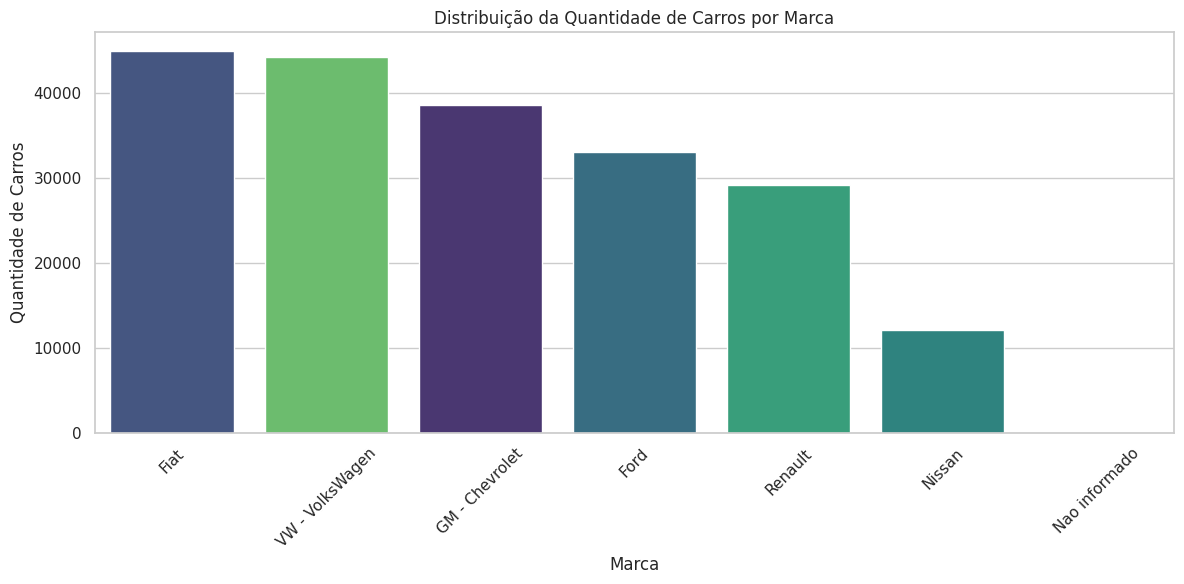

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(data=df_tratado, x='brand', hue='brand', order=df_tratado['brand'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribuição da Quantidade de Carros por Marca')
plt.xlabel('Marca')
plt.ylabel('Quantidade de Carros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**b.** Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro.



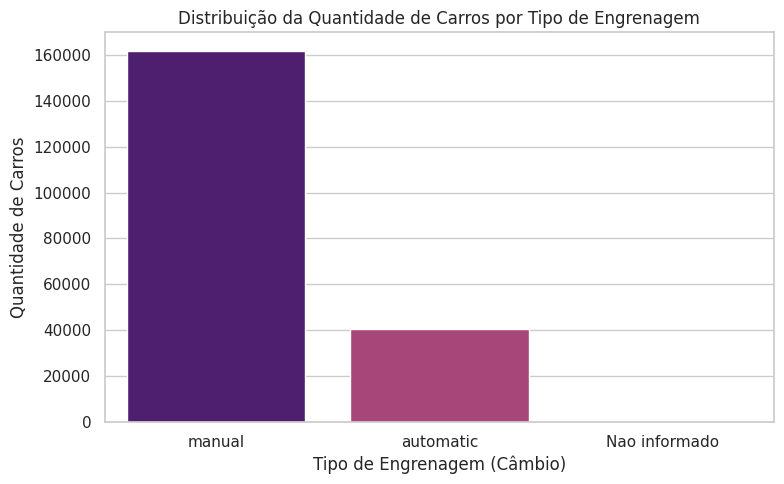

In [102]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_tratado, x='gear', hue='gear', order=df_tratado['gear'].value_counts().index, palette='magma', legend=False)
plt.title('Distribuição da Quantidade de Carros por Tipo de Engrenagem')
plt.xlabel('Tipo de Engrenagem (Câmbio)')
plt.ylabel('Quantidade de Carros')
plt.tight_layout()
plt.show()

**c.** Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X).

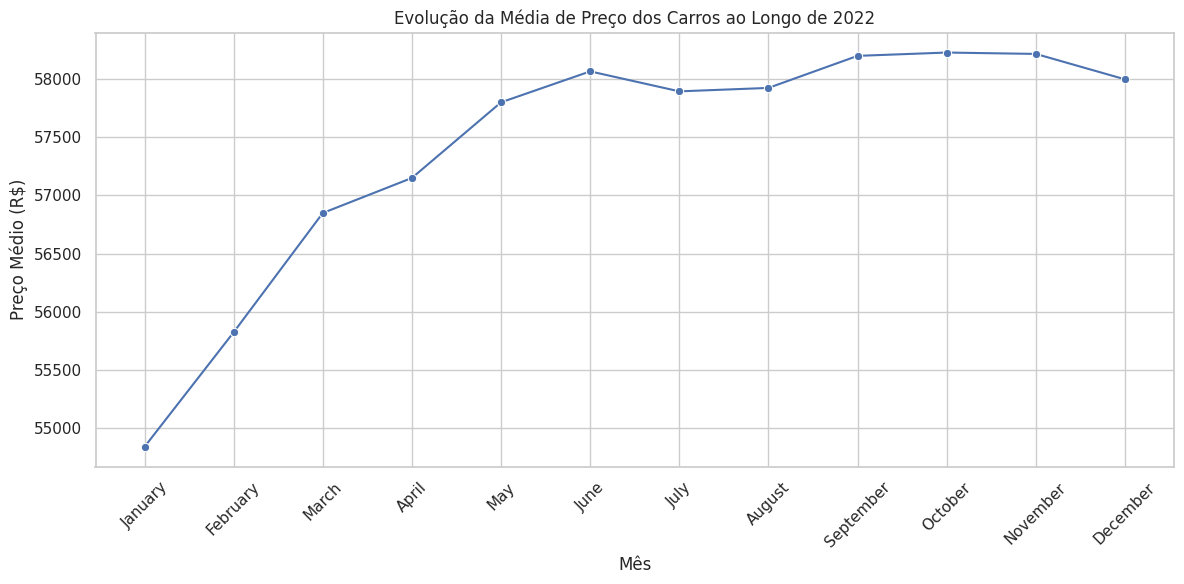

In [103]:
filtro_2022 = (df_tratado['year_of_reference'] == 2022) & (df_tratado['month_of_reference'] != 'Nao informado')
df_2022 = df_tratado[filtro_2022].copy()

meses_ordem = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

df_2022['month_of_reference'] = pd.Categorical(df_2022['month_of_reference'], categories=meses_ordem, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_2022, x='month_of_reference', y='avg_price_brl', errorbar=None, marker='o', color='b')
plt.title('Evolução da Média de Preço dos Carros ao Longo de 2022')
plt.xlabel('Mês')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**d.** Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem.

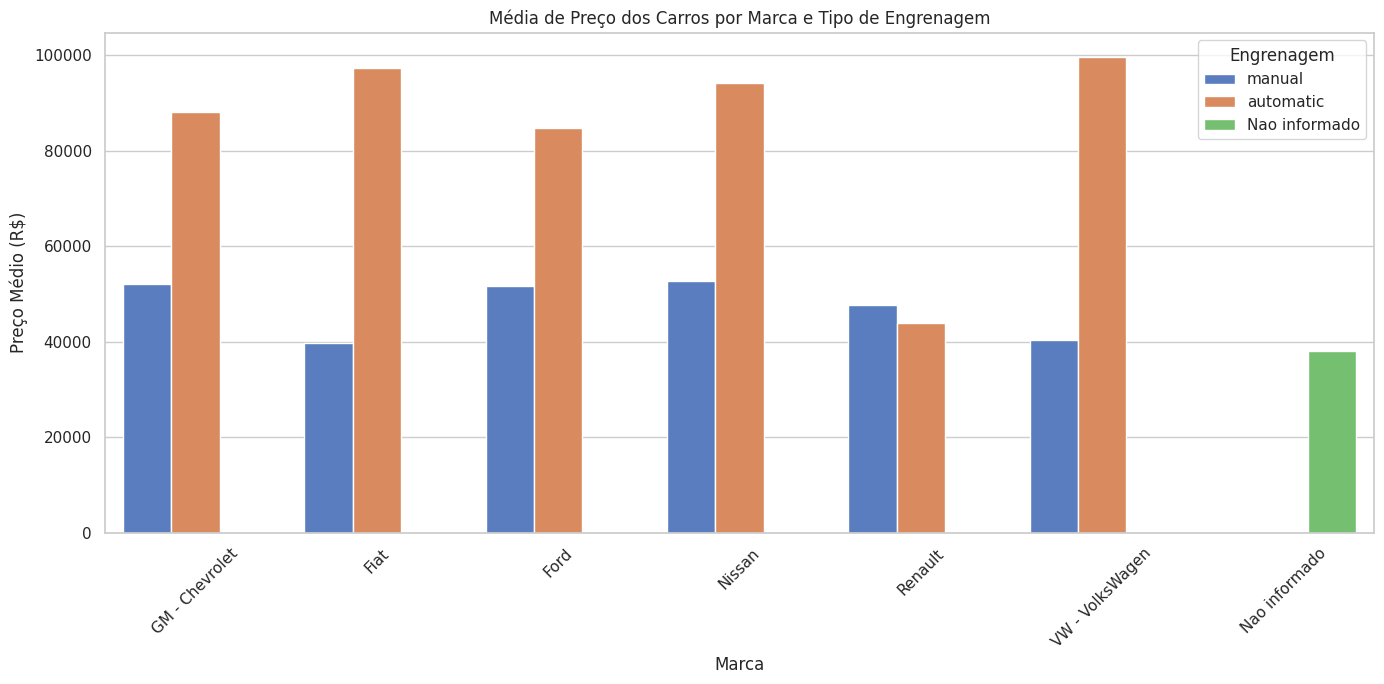

In [104]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_tratado, x='brand', y='avg_price_brl', hue='gear', errorbar=None, palette='muted')
plt.title('Média de Preço dos Carros por Marca e Tipo de Engrenagem')
plt.xlabel('Marca')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.legend(title='Engrenagem')
plt.tight_layout()
plt.show()

**e.** Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item d.

Os gráficos indicam que, em todas as marcas analisadas, os veículos com câmbio automático apresentam um preço médio consideravelmente superior aos de câmbio manual. Isso reflete o maior valor agregado dessa tecnologia e sua maior presença em categorias de veículos premium ou modelos mais completos no mercado.

**f.** Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de combustível.

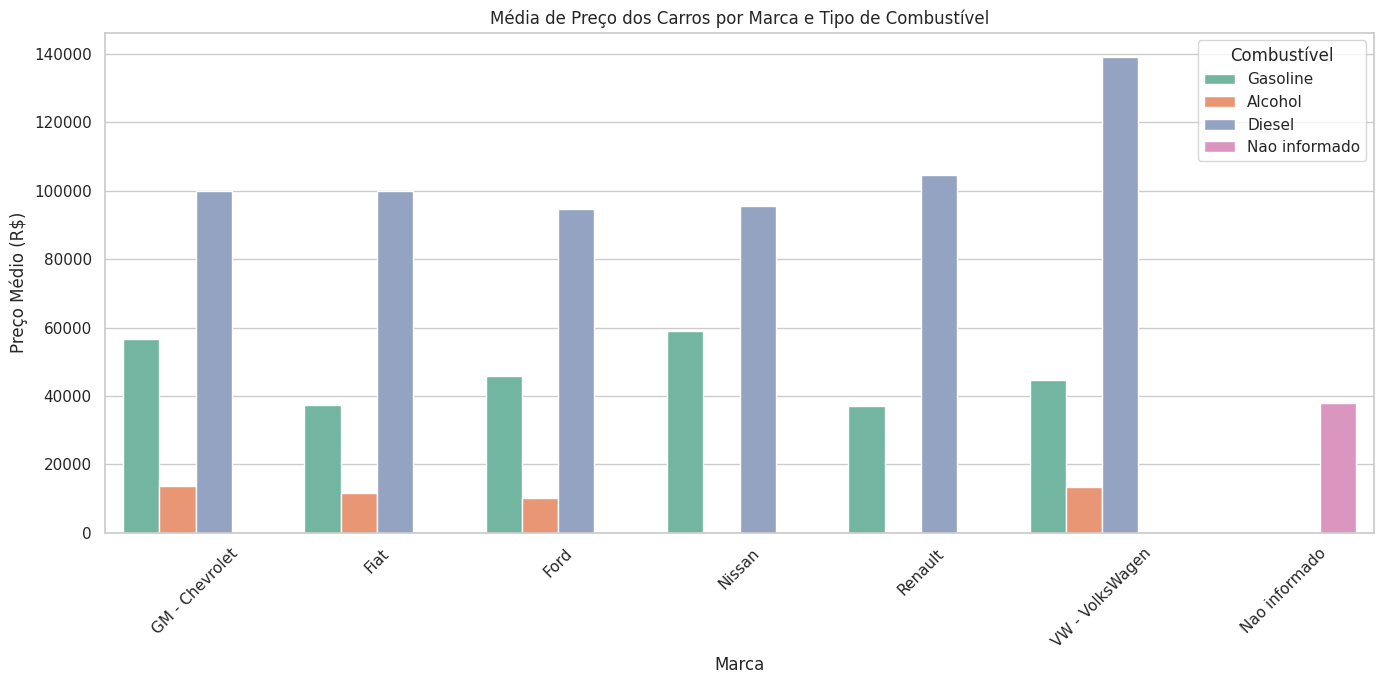

In [105]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_tratado, x='brand', y='avg_price_brl', hue='fuel', errorbar=None, palette='Set2')
plt.title('Média de Preço dos Carros por Marca e Tipo de Combustível')
plt.xlabel('Marca')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.legend(title='Combustível')
plt.tight_layout()
plt.show()

**g.** Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item f.

A visualização demonstra uma clara variação de preço médio ditada pelo combustível. Veículos movidos a diesel tendem a possuir as maiores médias de preço, pois esse combustível é tradicionalmente associado a picapes e SUVs de grande porte, enquanto veículos a gasolina e flex apresentam médias inferiores e mais equilibradas.

# 3 Aplicação de modelos de machine learning para prever o preço médio dos carros

A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:


In [5]:
#Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**a.** Escolha as variáveis numéricas (modelos de Regressão) para serem as variáveis independentes do modelo. A variável target é avg_price. Observação: caso julgue necessário, faça a transformação de variáveis categóricas em variáveis numéricas para inputar no modelo. Indique quais variáveis foram transformadas e como foram transformadas

In [6]:
# print(colunas_numericas)
# print(colunas_categoricas)

df_tratado['gear'] = LabelEncoder().fit_transform(df_tratado['gear']) 
print("Transformando gear para numero sendo manual (2), Automatico (1), Não informado (0)")
df_tratado.head()
dados_num = df_tratado.drop(['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'engine_size'],axis = 1)
print(dados_num)




Transformando gear para numero sendo manual (2), Automatico (1), Não informado (0)
        year_of_reference  gear  year_model  avg_price_brl
0                  2021.0     2      2002.0         9162.0
1                  2021.0     2      2001.0         8832.0
2                  2021.0     2      2000.0         8388.0
3                  2021.0     2      2000.0         8453.0
4                  2021.0     2      2001.0        12525.0
...                   ...   ...         ...            ...
202291             2023.0     2      2023.0        95997.0
202292             2023.0     2      2023.0        87828.0
202293             2023.0     2      2023.0        80845.0
202294             2023.0     2      2023.0        74458.0
202295             2022.0     0      2012.0        38027.0

[202296 rows x 4 columns]


In [7]:
X = dados_num.drop(['avg_price_brl'],axis = 1)
X.head()

Y = dados_num['avg_price_brl']
Y.head()

0     9162.0
1     8832.0
2     8388.0
3     8453.0
4    12525.0
Name: avg_price_brl, dtype: float64

**b.** Crie partições contendo 75% dos dados para treino e 25% para teste

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [119]:
print("Dados de treinamento")
print(X_train.shape)
X_train.head(1)

Dados de treinamento
(151722, 3)


,year_of_reference,gear,year_model
156363,2022.0,2,2020.0


In [120]:
print("Dados de teste")
print(X_test.shape)
X_test.head(1)

Dados de teste
(50574, 3)


,year_of_reference,gear,year_model
180633,2022.0,2,2014.0


In [121]:
print("Variavel Target")
Y_test.head()

Variavel Target


180633    41426.0
13130     10989.0
163315    27673.0
121463    26965.0
14044     57102.0
Name: avg_price_brl, dtype: float64

**c.** Treine modelos RandomForest (biblioteca RandomForestRegressor) e XGBoost (biblioteca XGBRegressor) para predição dos preços dos carros. Observação: caso julgue necessário, mude os parâmetros dos modelos e rode novos modelos. Indique quais parâmetros foram inputados e indique o treinamento de cada modelo


In [9]:
print("Treinando modelo RandomForestRegressor")
model_rf = RandomForestRegressor(random_state=42, n_estimators=200)
model_rf.fit(X_train, Y_train)

print("Treinando modelo XGBRegressor")
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )
model_xgb.fit(X_train, Y_train)

Treinando modelo RandomForestRegressor
Treinando modelo XGBRegressor


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

**d.** Grave os valores preditos em variáveis criadas

In [127]:
valores_preditos_rf = model_rf.predict(X_test)
valores_preditos_rf

array([57196.962187  , 24151.61008256, 30076.30706187, ...,
       39282.87218612, 22000.68578773, 29579.35783261])

**e.** Realize a análise de importância das variáveis para estimar a variável target, para cada modelo treinado

In [21]:
importancia_rf = pd.DataFrame({
    'variavel': X_train.columns,
    'importancia': model_rf.feature_importances_,
    'modelo': 'RandomForestRegressor'
}).sort_values('importancia', ascending=False)

importancia_xgb = pd.DataFrame({
    'variavel': X_train.columns,
    'importancia': model_xgb.feature_importances_,
    'modelo': 'XGBRegressor'
}).sort_values('importancia', ascending=False)

print('Importância das variáveis - RandomForestRegressor:')
display(importancia_rf)

print('Importância das variáveis - XGBRegressor:')
display(importancia_xgb)

Importância das variáveis - RandomForestRegressor:


,variavel,importancia,modelo
2,year_model,0.918744,RandomForestRegressor
1,gear,0.058232,RandomForestRegressor
0,year_of_reference,0.023024,RandomForestRegressor


Importância das variáveis - XGBRegressor:


,variavel,importancia,modelo
1,gear,0.484537,XGBRegressor
2,year_model,0.473847,XGBRegressor
0,year_of_reference,0.041617,XGBRegressor


**f.** Dê uma breve explicação (máximo de quatro linhas) sobre os resultados encontrados na análise de importância de variáveis

In [ ]:
#No Random Forest, year_model foi a variável mais importante, seguida por gear e year_of_reference.
#Já no XGBoost, gear e year_model concentraram as maiores importâncias, com valores muito próximos.
#Em ambos os modelos, year_of_reference teve contribuição menor na previsão de avg_price_brl.
#Logo, o preço é explicado principalmente por características do veículo e do tipo de câmbio.

No Random Forest, year_model foi a variável mais importante, seguida por gear e year_of_reference.
No XGBoost, gear e year_model concentraram as maiores importâncias, com valores muito próximos.
Em ambos os modelos, year_of_reference teve contribuição menor na previsão de avg_price_brl.
Logo, o preço é explicado principalmente por características do veículo e do tipo de câmbio.


**g.** Escolha o melhor modelo com base nas métricas de avaliação MSE, MAE e R²

In [18]:
valores_preditos_rf = model_rf.predict(X_test)
valores_preditos_xgb = model_xgb.predict(X_test)

metricas_modelos = pd.DataFrame({
    'modelo': ['RandomForestRegressor', 'XGBRegressor'],
    'MSE': [
        mean_squared_error(Y_test, valores_preditos_rf),
        mean_squared_error(Y_test, valores_preditos_xgb)
    ],
    'MAE': [
        mean_absolute_error(Y_test, valores_preditos_rf),
        mean_absolute_error(Y_test, valores_preditos_xgb)
    ],
    'R2': [
        r2_score(Y_test, valores_preditos_rf),
        r2_score(Y_test, valores_preditos_xgb)
    ]
})

print("Comparação de métricas dos modelos:")
display(metricas_modelos)

Comparação de métricas dos modelos:


,modelo,MSE,MAE,R2
0,RandomForestRegressor,1.608043e+09,22100.971113,0.390254
1,XGBRegressor,1.607656e+09,22089.126630,0.390401


In [13]:
melhor_modelo = metricas_modelos.sort_values(by=['R2', 'MAE'], ascending=[False, True]).iloc[0]

print("Melhor modelo encontrado:")
display(melhor_modelo.to_frame().T)

Melhor modelo encontrado:


,modelo,MSE,MAE,R2
1,XGBRegressor,1607655850.955437,22089.12663,0.390401


In [19]:
print(f"Modelo vencedor: {melhor_modelo['modelo']}")
print(f"MSE: {melhor_modelo['MSE']:.2f}")
print(f"MAE: {melhor_modelo['MAE']:.2f}")
print(f"R²: {melhor_modelo['R2']:.4f}")

Modelo vencedor: XGBRegressor
MSE: 1607655850.96
MAE: 22089.13
R²: 0.3904


**h.** Dê uma breve explicação (máximo de quatro linhas) sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada


In [23]:
print(f"O melhor modelo foi {melhor_modelo['modelo']}, por apresentar maior R² ({melhor_modelo['R2']:.4f}).")
print(f"Além disso, ele também apresentou menores erros: MAE = {melhor_modelo['MAE']:.2f} e MSE = {melhor_modelo['MSE']:.2f}.")
print('A métrica principal adotada foi o R², usando MAE e MSE como critérios complementares de desempate.')
print('Portanto, esse modelo foi o mais adequado para esta base e configuração de treino/teste.')

O melhor modelo foi XGBRegressor, por apresentar maior R² (0.3904).
Além disso, ele também apresentou menores erros: MAE = 22089.13 e MSE = 1607655850.96.
A métrica principal adotada foi o R², usando MAE e MSE como critérios complementares de desempate.
Portanto, esse modelo foi o mais adequado para esta base e configuração de treino/teste.
